# NumPy for Probability and Statistics: Iris Practice


## 1. Setup

Load NumPy, Matplotlib, and the Iris dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

rng = np.random.default_rng(42)

main_color = "#7AA6C2"
class_colors = ["#7CB7A3", "#E6A86E", "#9A8BC2"]

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = np.array(iris.feature_names)
target_names = np.array(iris.target_names)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Feature names:", feature_names.tolist())
print("Class names:", target_names.tolist())

X shape: (150, 4)
y shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa', 'versicolor', 'virginica']


In [ ]:
print("First five feature rows:")
print(X[:5])

print("\nClass indices:")
print(y[:5])

print("\nClass names:")
print(target_names[y[:5]])


First five feature rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Class indices:
[0 0 0 0 0]

Class names:
['setosa' 'setosa' 'setosa' 'setosa' 'setosa']


## 2. Random Variables in Iris

$Y$ is the flower class, a discrete random variable. Each $X_j$ is a numerical feature that can be treated as a continuous random variable.

Each row is one observed outcome of these random variables.

In [ ]:
flower_index = 0

print("Features:", X[flower_index])
print("Class index:", y[flower_index])
print("Class name:", target_names[y[flower_index]])

Features: [5.1 3.5 1.4 0.2]
Class index: 0
Class name: setosa


## 3. Empirical Class Probability

If one row is sampled uniformly from this dataset, class probability can be estimated from relative frequency.

$
\hat{P}(Y=c)
=
\frac{\text{number of rows in class }c}
{\text{total number of rows}}
$

In [ ]:
class_counts = np.bincount(y)
class_probabilities = class_counts / len(y)

for class_index, class_name in enumerate(target_names):
    print(
        f"{class_name}: "
        f"count = {class_counts[class_index]}, "
        f"probability = {class_probabilities[class_index]:.3f}"
    )

setosa: count = 50, probability = 0.333
versicolor: count = 50, probability = 0.333
virginica: count = 50, probability = 0.333


These probabilities describe uniform sampling from the 150 dataset rows. They do not estimate class prevalence in nature.

In [ ]:
sampled_indices = rng.choice(len(X), size=50000, replace=True)

print("Sampled indices:", sampled_indices)
print("Sampled classes:", target_names[y[sampled_indices]])
print("Sampled features:")
print(X[sampled_indices])


Sampled indices: [128  99 100 ...  40  43 140]
Sampled classes: ['virginica' 'versicolor' 'virginica' ... 'setosa' 'setosa' 'virginica']
Sampled features:
[[6.4 2.8 5.6 2.1]
 [5.7 2.8 4.1 1.3]
 [6.3 3.3 6.  2.5]
 ...
 [5.  3.5 1.3 0.3]
 [5.  3.5 1.6 0.6]
 [6.7 3.1 5.6 2.4]]


## 4. Feature-wise Descriptive Statistics

For `X.shape == (n_samples, n_features)`, using `axis=0` returns one statistic per feature.

In [ ]:
feature_mean = np.mean(X, axis=0)
feature_median = np.median(X, axis=0)
feature_variance = np.var(X, axis=0)
feature_std = np.std(X, axis=0)
feature_quartiles = np.percentile(X, [25, 50, 75], axis=0)

for index, feature_name in enumerate(feature_names):
    print(f"\n{feature_name}")
    print(f"  mean     = {feature_mean[index]:.3f}")
    print(f"  median   = {feature_median[index]:.3f}")
    print(f"  variance = {feature_variance[index]:.3f}")
    print(f"  std      = {feature_std[index]:.3f}")
    print(f"  Q1, Q3   = {feature_quartiles[0, index]:.3f}, "
          f"{feature_quartiles[2, index]:.3f}")



sepal length (cm)
  mean     = 5.843
  median   = 5.800
  variance = 0.681
  std      = 0.825
  Q1, Q3   = 5.100, 6.400

sepal width (cm)
  mean     = 3.057
  median   = 3.000
  variance = 0.189
  std      = 0.434
  Q1, Q3   = 2.800, 3.300

petal length (cm)
  mean     = 3.758
  median   = 4.350
  variance = 3.096
  std      = 1.759
  Q1, Q3   = 1.600, 5.100

petal width (cm)
  mean     = 1.199
  median   = 1.300
  variance = 0.577
  std      = 0.760
  Q1, Q3   = 0.300, 1.800


The sample mean summarizes observed values and can be interpreted as an estimate of the feature's expected value.

Mean should be read together with median and standard deviation.

In [ ]:
axis_0_shape = np.mean(X, axis=0).shape
axis_1_shape = np.mean(X, axis=1).shape

print("axis=0 -> one value per feature:", axis_0_shape)
print("axis=1 -> one value per sample:", axis_1_shape)

axis=0 -> one value per feature: (4,)
axis=1 -> one value per sample: (150,)


## 5. Mean, Median, and an Outlier

The mean uses every value. The median depends on position and is usually less sensitive to an extreme value.

In [ ]:
petal_length = X[:, 2]

petal_length_with_outlier = petal_length.copy()
petal_length_with_outlier[0] = 30.0

original_mean = np.mean(petal_length)
original_median = np.median(petal_length)
outlier_mean = np.mean(petal_length_with_outlier)
outlier_median = np.median(petal_length_with_outlier)

print(f"Original mean:       {original_mean:.3f}")
print(f"Original median:     {original_median:.3f}")
print(f"Mean with outlier:   {outlier_mean:.3f}")
print(f"Median with outlier: {outlier_median:.3f}")
print(f"Change in mean:      {outlier_mean - original_mean:.3f}")
print(f"Change in median:    {outlier_median - original_median:.3f}")

Original mean:       3.758
Original median:     4.350
Mean with outlier:   3.949
Median with outlier: 4.400
Change in mean:      0.191
Change in median:    0.050


The outlier changes the mean more strongly than the median. Neither measure should be interpreted without inspecting the data distribution.

## 6. Feature Distributions

A histogram groups continuous values into intervals and shows how frequently observations fall into each interval.

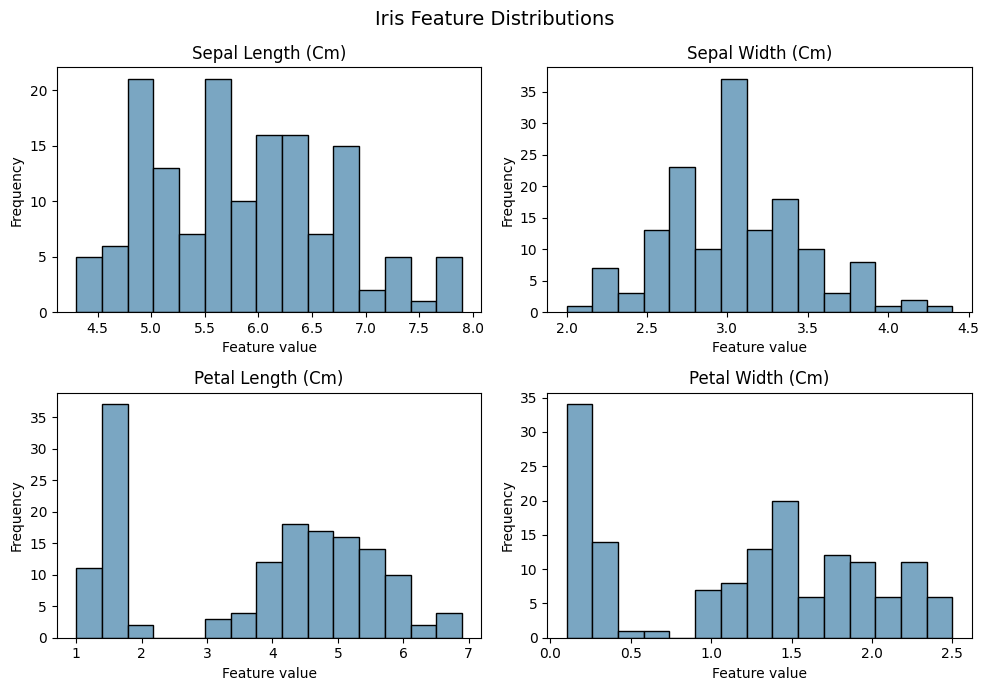

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for feature_index, ax in enumerate(axes.flat):
    ax.hist(
        X[:, feature_index],
        bins=15,
        color=main_color,
        edgecolor="black",
    )
    ax.set_title(feature_names[feature_index].title())
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Frequency")

fig.suptitle("Iris Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()


Observe whether each feature is symmetric, skewed, or multimodal. Multiple peaks may reflect different Iris classes.

## 7. Iris Data and a Gaussian Reference

A Gaussian distribution is determined by its mean and standard deviation. Real data with the same mean and standard deviation may still have a different shape.

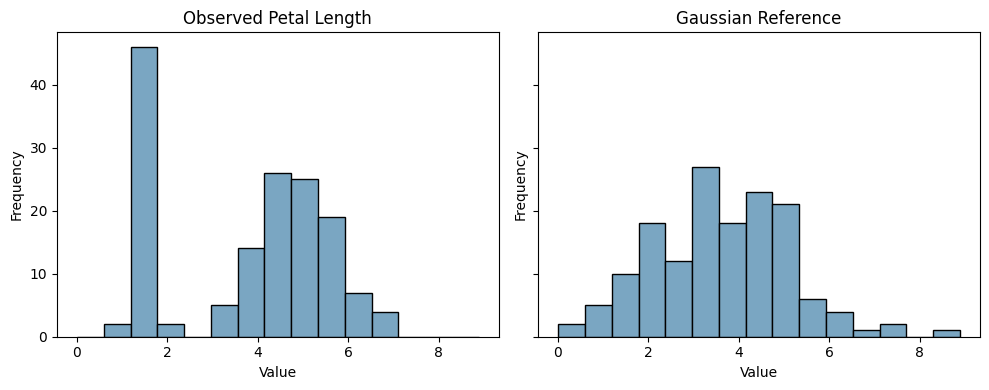

Observed: mean=3.76, std=1.76
Gaussian sample: mean=3.64, std=1.51


In [ ]:
petal_mean = np.mean(petal_length)
petal_std = np.std(petal_length)

gaussian_reference = rng.normal(
    loc=petal_mean,
    scale=petal_std,
    size=len(petal_length),
)

common_range = (
    min(petal_length.min(), gaussian_reference.min()),
    max(petal_length.max(), gaussian_reference.max()),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(
    petal_length,
    bins=15,
    range=common_range,
    color=main_color,
    edgecolor="black",
)
axes[0].set_title("Observed Petal Length")

axes[1].hist(
    gaussian_reference,
    bins=15,
    range=common_range,
    color=main_color,
    edgecolor="black",
)
axes[1].set_title("Gaussian Reference")

for ax in axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Observed: mean={petal_mean:.2f}, std={petal_std:.2f}")
print(
    "Gaussian sample: "
    f"mean={np.mean(gaussian_reference):.2f}, "
    f"std={np.std(gaussian_reference):.2f}"
)


The two datasets have similar mean and standard deviation, but their distribution shapes are different.

This shows why summary statistics and histograms should be used together.

## 8. Z-score Standardization

Standardization transforms each feature using:

$
z=\frac{x-\mu}{\sigma}
$

The transformation is applied independently to each feature.

In [ ]:
feature_mean = np.mean(X, axis=0)
feature_std = np.std(X, axis=0)

X_standardized = (X - feature_mean) / feature_std

print("Standardized feature means:")
print(np.mean(X_standardized, axis=0))

print("\nStandardized feature standard deviations:")
print(np.std(X_standardized, axis=0))


Standardized feature means:
[-0. -0. -0. -0.]

Standardized feature standard deviations:
[1. 1. 1. 1.]


## 9. Covariance and Correlation

Covariance describes the direction of joint variation. Correlation standardizes this relationship to a value between -1 and 1.

In [ ]:
covariance_matrix = np.cov(X, rowvar=False, ddof=0)
correlation_matrix = np.corrcoef(X, rowvar=False)

print("Covariance matrix:")
print(covariance_matrix)

print("\nCorrelation matrix:")
print(correlation_matrix)

print("\nCovariance diagonal:")
print(np.diag(covariance_matrix))

print("\nFeature variances:")
print(np.var(X, axis=0))


Covariance matrix:
[[ 0.681 -0.042  1.266  0.513]
 [-0.042  0.189 -0.327 -0.121]
 [ 1.266 -0.327  3.096  1.287]
 [ 0.513 -0.121  1.287  0.577]]

Correlation matrix:
[[ 1.    -0.118  0.872  0.818]
 [-0.118  1.    -0.428 -0.366]
 [ 0.872 -0.428  1.     0.963]
 [ 0.818 -0.366  0.963  1.   ]]

Covariance diagonal:
[0.681 0.189 3.096 0.577]

Feature variances:
[0.681 0.189 3.096 0.577]


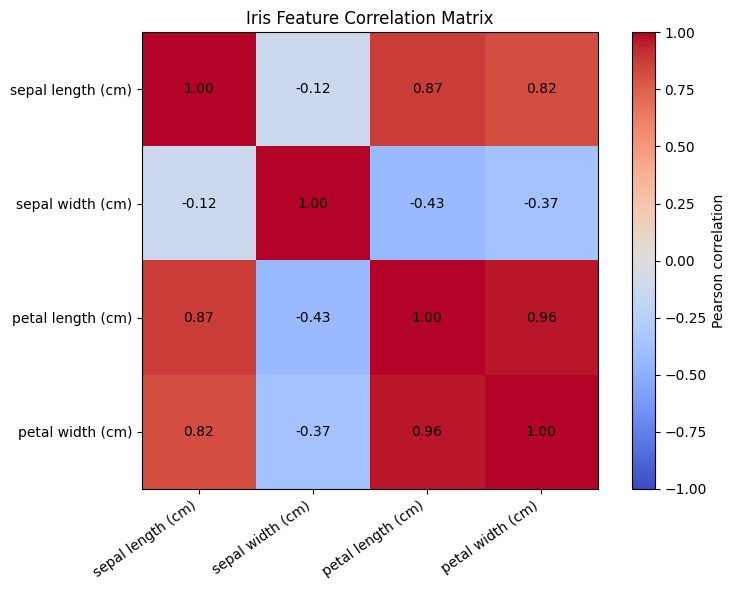

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=35, ha="right")
ax.set_yticklabels(feature_names)
ax.set_title("Iris Feature Correlation Matrix")

for row in range(len(feature_names)):
    for column in range(len(feature_names)):
        ax.text(
            column,
            row,
            f"{correlation_matrix[row, column]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(ax.images[0], ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()


In [ ]:
petal_correlation = correlation_matrix[2, 3]

print("Feature pair:")
print(feature_names[2], "and", feature_names[3])
print(f"Correlation: {petal_correlation:.3f}")


Feature pair:
petal length (cm) and petal width (cm)
Correlation: 0.963


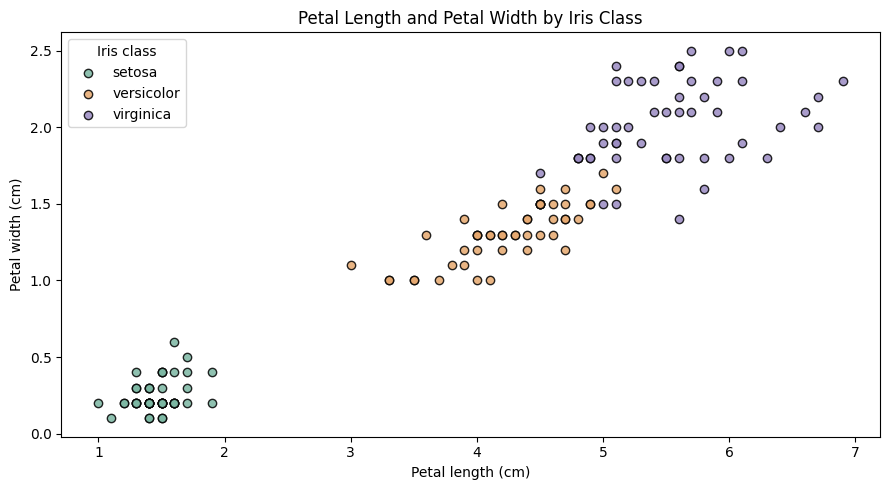

In [ ]:
petal_width = X[:, 3]

fig, ax = plt.subplots(figsize=(9, 5))

for class_index in range(len(target_names)):
    class_mask = y == class_index

    ax.scatter(
        petal_length[class_mask],
        petal_width[class_mask],
        label=target_names[class_index],
        color=class_colors[class_index],
        edgecolor="black",
        alpha=0.85,
    )

ax.set_title("Petal Length and Petal Width by Iris Class")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.legend(title="Iris class")
plt.tight_layout()
plt.show()